# nuScenes Dataset Tutorial

**Objectives**
- Visualize camera images and object label
- Visualize camera iamges and map label

In [182]:
import cv2
import numpy as np

from typing import List, Dict

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import Box
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
%matplotlib inline

## Initialize

Initialize dataset and pick a sample

In [311]:
DATASET_PATH = '/mnt/dataset/nuscenes/v1.0-mini'

# Get nuScenes data sample
nusc = NuScenes(version='v1.0-mini', dataroot=DATASET_PATH, verbose=False)
sample = nusc.sample[0]

# Set camera visualization order
camera_order = [
     'CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT',
    'CAM_BACK_LEFT',  'CAM_BACK',  'CAM_BACK_RIGHT'
]

# Set object class color
class_color = {
    'vehicle.car': 'red',
    'vehicle.truck': 'orange',
    'vehicle.bus.bendy': 'darkorange',
    'vehicle.bus.rigid': 'gold',
    'vehicle.motorcycle': 'purple',
    'vehicle.bicycle': 'blue',
    'human.pedestrian.adult': 'green',
    'human.pedestrian.child': 'lime',
    'movable_object.barrier': 'brown',
    'movable_object.trafficcone': 'pink',
}

# Set map layers and its style
layers_and_styles = {
    'lane':           {'color': 'blue',   'ls': '-',  'lw': 1},
    'road_segment':   {'color': 'gray',   'ls': '-',  'lw': 1},
    'walkway':        {'color': 'green',  'ls': '--', 'lw': 1},
    'ped_crossing':   {'color': 'orange', 'ls': ':',  'lw': 2},
    'stop_line':      {'color': 'red',    'ls': '-.', 'lw': 2},
}

In [303]:
# Define transform matrix converting from global to local frame
def transform_matrix_2d(translation: List, rotation: List):
    x, y, _ = translation
    yaw, _, _ = Quaternion(rotation).yaw_pitch_roll
    c, s = np.cos(yaw), np.sin(yaw)
    T = np.array([
        [c, -s, x],
        [s,  c, y],
        [0,  0, 1]
    ])
    return np.linalg.inv(T)

def transform_matrix_3d(translation: List, rotation: List):
    T = np.eye(4)
    T[:3, :3] = Quaternion(rotation).rotation_matrix
    T[:3, 3] = np.array(translation)
    return np.linalg.inv(T)

def bbox2sensor(box: Box, sensor_pose: Dict):
    # Move box to sensor coord system.
    bbox = box.copy()
    bbox.translate(-np.array(sensor_pose['translation']))
    bbox.rotate(Quaternion(sensor_pose['rotation']).inverse)
    return bbox
    
# Get ego pose and transform matrix
ego_pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
T = transform_matrix_2d(translation=ego_pose['translation'], rotation=ego_pose['rotation'])

## Visualize dataset

ego pose: [411.3039349319818, 1180.8903791765097, 0.0]
ego ypr: (-1.9236730945067646, 0.016283235532639443, 0.01741295905383045)
cam pose: [411.36921032161575, 1181.0634380795361, 0.0]
cam ypr: (-1.923757934533581, 0.016654017124562163, 0.016947930832481826)


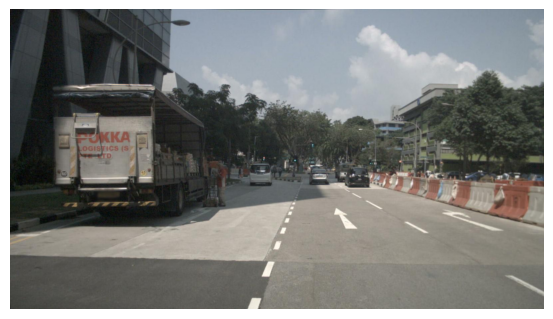

In [312]:
# Create figure
L = 80
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, figure=fig)  # Above 2x3 cells are camera images and below is for BEV
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)  # No spaces
    
# Visualize camera images 
for i, cam_name in enumerate(camera_order):
    data = nusc.get('sample_data', sample['data'][cam_name])
    cam_pose = nusc.get('ego_pose', cam_data['ego_pose_token'])
    calib = nusc.get('calibrated_sensor', data['calibrated_sensor_token'])
    
    img = cv2.imread(nusc.dataroot + '/' + data['filename'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax_cam = fig.add_subplot(gs[i // 3, i % 3])
    ax_cam.imshow(img)
    ax_cam.axis('off')

    t1 = ego_pose['translation']
    ypr1 = Quaternion(ego_pose['rotation']).yaw_pitch_roll
    print(f'ego pose: {t1}')
    print(f'ego ypr: {ypr1}')

    t2 = cam_pose['translation']
    ypr2 = Quaternion(cam_pose['rotation']).yaw_pitch_roll
    print(f'cam pose: {t2}')
    print(f'cam ypr: {ypr2}')
    
    break
    # for token in sample['anns']:
    #     # Get annotation bounding box
    #     ann = nusc.get('sample_annotation', token)
    #     box = Box(ann['translation'], ann['size'], Quaternion(ann['rotation']))

    #     try:
    #         # Coordinate conversion
    #         bbox = bbox2sensor(box, cam_pose)
    #         corners = bbox.corners()  # shape: (3, 8)
    #         corners = corners / corners[0]  # normalize by depth
    #         K = np.array(calib['camera_intrinsic'])
    #         z, u, v = K @ corners
    #     except:
    #         continue

    #     u_min, u_max = ax_cam.get_xlim()
    #     v_max, v_min = ax_cam.get_ylim()

    #     # print(f'K: {K}')
    #     # print(f'u_min: {u_min}, u_max: {u_max}')
    #     # print(f'v_min: {v_min}, v_max: {v_max}')
    #     # print(f'us: {us}')
    #     # print(f'vs: {vs}')
        
    #     if np.all(u > u_min) and np.all(u < u_max) and np.all(v > v_min) and np.all(v < v_max):
    #         ax_cam.plot(u, v, color='cyan', linewidth=1.0)

        # 2D projection된 box 그리기
        # ax_cam.plot(
        #     [corners[0, 0], corners[1, 0], corners[2, 0], corners[0, 0]], 
        #     [corners[1, 1], corners[2, 1], corners[0, 1], corners[1, 1]], 
        #     color='cyan', linewidth=1.0)

        # ax_cam.plot(
        #     [corners[4, 0], corners[5, 0], corners[6, 0], corners[7, 0], corners[4, 0]], 
        #     [corners[5, 1], corners[6, 1], corners[7, 1], corners[4, 1], corners[5, 1]], 
        #     color='cyan', linewidth=1.0)

        # for k in range(4):
        #     ax_cam.plot(
        #         [corners[k, 0], corners[k+4, 0]],
        #         [corners[k, 1], corners[k+4, 1]],
        #         color='cyan', linewidth=1.0)

## BEV - Map

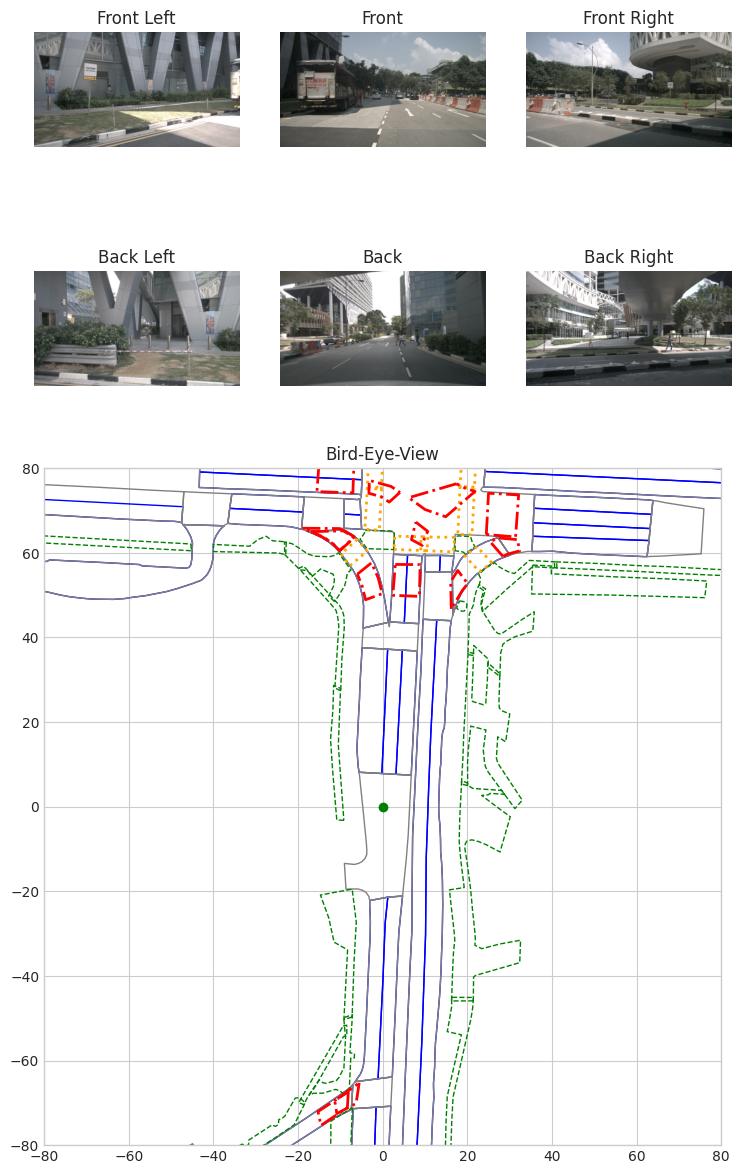

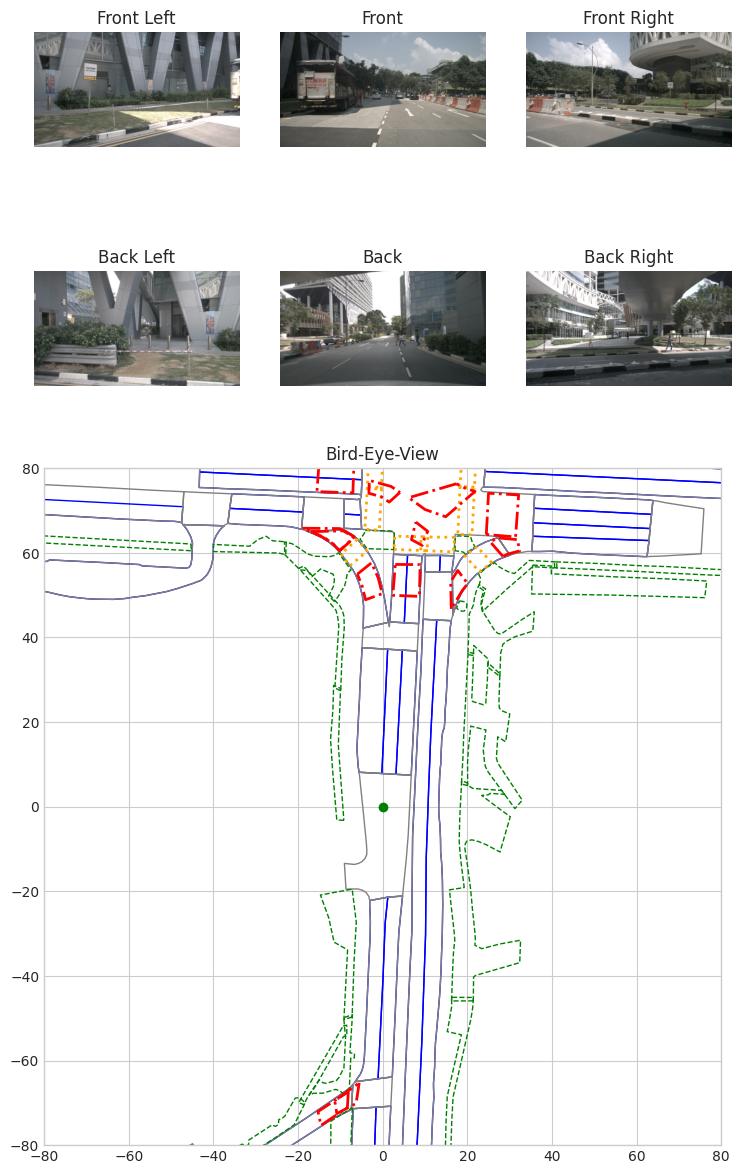

In [119]:
from nuscenes.map_expansion.map_api import NuScenesMap
from shapely.geometry import Polygon, LineString
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon

L = 80
fig = plt.figure(figsize=(9, 15))

camera_order = [
    'CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
    'CAM_BACK_LEFT',  'CAM_BACK',  'CAM_BACK_RIGHT'
]

camera_images = []
for cam in camera_order:
    data = nusc.get('sample_data', sample['data'][cam])
    img = cv2.imread(nusc.dataroot + '/' + data['filename'])
    camera_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

for i, img in enumerate(camera_images):
    ax_cam = fig.add_subplot(5, 3, i+1)
    ax_cam.imshow(img)
    ax_cam.set_title(camera_order[i].replace("CAM_", "").replace("_", " ").title())
    ax_cam.axis('off')

# Ego pose
ego_pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
ego_translation = np.array(ego_pose['translation'][0:2])
ego_rotation = Quaternion(ego_pose['rotation'])
yaw_angle = ego_rotation.yaw_pitch_roll[0]  # yaw [rad]

scene = nusc.get('scene', nusc.sample[0]['scene_token'])
log = nusc.get('log', scene['log_token'])
location = log['location']  # e.g., 'boston-seaport'
nusc_map = NuScenesMap(dataroot=nusc.dataroot, map_name=location)

layers_and_styles = {
    'lane':           {'color': 'blue',   'ls': '-',  'lw': 1},
    'road_segment':   {'color': 'gray',   'ls': '-',  'lw': 1},
    'walkway':        {'color': 'green',  'ls': '--', 'lw': 1},
    'ped_crossing':   {'color': 'orange', 'ls': ':',  'lw': 2},
    'stop_line':      {'color': 'red',    'ls': '-.', 'lw': 2},
}

gs = gridspec.GridSpec(5, 3, figure=fig)
ax_bev = fig.add_subplot(gs[2:, :])

ax_bev.set_title('Bird-Eye-View')
ax_bev.set_xlim(-L, L)
ax_bev.set_ylim(-L, L)
ax_bev.set_aspect('equal')

for layer_name, style in layers_and_styles.items():
    tokens = nusc_map.get_records_in_radius(
        ego_translation[0], ego_translation[1], L, layer_names=[layer_name]
    )[layer_name]

    for token in tokens:
        record = nusc_map.get(layer_name, token)
        polygon_token = record.get('polygon_token')
        line_token = record.get('line_token')
        
        if polygon_token:
            polygon = nusc_map.extract_polygon(polygon_token)
            coords = np.array(polygon.exterior.coords)
        elif line_token:
            line = nusc_map.extract_line(line_token)
            coords = np.array(line.coords)
        else:
            continue

        # local frame 변환
        coords = (coords - ego_translation).T
        coords = rotate_to_ego_frame(coords, yaw_angle - np.pi/2).T  # shape (N, 2)

        # 그리기
        ax_bev.plot(coords[:, 0], coords[:, 1],
                color=style['color'],
                linestyle=style['ls'],
                linewidth=style['lw'],
                label=layer_name)

# ego 표시
ax_bev.plot(0, 0, 'go', label='ego')

# 중복 legend 제거
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax_bev.legend(unique.values(), unique.keys())

fig